## 7. Features - Merkmale von Datensätzen

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=aNVkTrCS6lE&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience07.png)](https://www.youtube.com/watch?v=aNVkTrCS6lE&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

**Klassifikation** sagt *diskrete Labels (Ergebnisse)* voraus, z. B. ``yes/no``, ``True/False`` oder eine endliche Anzahl diskreter Stufen wie einen Buchstaben bei Texterkennung. Ein Beispiel für Klassifikation ist die Empfehlung eines Films, den du als Nächstes sehen möchtest (Label), basierend auf deiner bisherigen Sehgeschichte (Feature). **Regression** unterscheidet sich davon durch kontinuierliche Ergebnisse, z. B. beliebige Gleitkommazahlen in einem Bereich. Ein Beispiel für Regression ist der Aufbau einer Korrelation für die Temperatur eines Topfs mit Wasser (Label) basierend auf der Heizdauer (Feature). Die Temperaturwerte sind kontinuierlich, während der nächste Film eine von vielen diskreten Optionen ist.

![list](https://apmonitor.com/che263/uploads/Begin_Python/list.png)

Features sind Eingabewerte für Regressions- oder Klassifikationsmodelle.
Die Labels sind die gemessenen Ergebnisse und entsprechen einer Zuordung (heiß/kalt Kochtopf mit Wasser, Katze/Hund/Pinguin bei Bildklassifikation).
Untenstehende Tabelle enthält Begriffe aus Machine Learning, Optimierung, Methoden in ``GEKKO`` und eine Beschreibung.

| **Machine Learning** | **Bedeutung** | **Gekko-Parameter** | **Beschreibung** |
| ----------- | ----------- | ----------- | ----------- |
| Loss | Zielfunktion | `m.Minimize()` | Die mathematische Größe, die den Unterschied zwischen vorhergesagten und gemessenen Ergebnissen repräsentiert |
| Weights | Einstellbare Parameter | Feste Werte (`m.FV()`) mit `STATUS=1` | Einstellbare Paramter zur Minimierung der Zielfunktion (Loss)
| Label | Gemessenes Ergebnis | Regelgröße (`m.CV()`) mit `FSTATUS=1` | Messungen des vorhergesagten Systemausgangs |
| Feature | Gemessene Eingabe | Parameter (`m.Param()`) | Eingangsmessungen, die das Ergebnis-Label vorhersagen |
| Train | Optimieren | Lösen (`m.solve()`) | Unbekannte Parameter (Weights) anpassen, um die Zielfunktion (Loss) zu minimieren
| Test | Evaluieren | Lösen mit `STATUS=0` für `m.FV()` | Labels mit dem abgestimmten Modell vorhersagen, um die Leistung des Klassifikators oder Regressors zu bewerten | 
| Regressor oder Classifier | Modell | `m = GEKKO()` | Mathematische Gleichungen und Parameter, die Feature-Eingaben nutzen, um ein Ergebnis-Label vorherzusagen |

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

Die Auswahl und Erstellung von Features ist ein wichtiger Schritt im Machine Learning. Zu viele Features können die Wahrscheinlichkeit schlechter Vorhersagen durch Klassifikator oder Regressor erhöhen. Bei vielen Features kann einer der Eingaben ein fehlerhafter Wert sein und zu einer schlechten Vorhersage führen. Mehr Features bedeuten außerdem mehr Zeit für Datenaufbereitung, Training und Vorhersage. Diese Lektion zeigt, wie man Features für Regression und Klassifikation ableitet und auswählt.

![analyze](https://apmonitor.com/che263/uploads/Begin_Python/analyze.png)

### Identify Features and Label

Der erste Schritt beim Erstellen eines Regressors oder Klassifikators ist festzulegen, welche Messungen (Eingabefeatures und Ausgabelabel) verfügbar sind. Du kannst die Datenspalten als Features auswählen oder mit einem Paket wie tsfresh erzeugen.

Du könntest z. B. Börsendaten verwenden, um einen Indikator zu erhalten, wann du kaufen (1) oder verkaufen (-1) solltest. Dieser Indikator ist ein Label. Importiere die täglichen Kursdaten von Google für 23 Tage.

In [2]:
import pandas as pd
import numpy as np
url = 'http://apmonitor.com/che263/uploads/Main/goog.csv'
data = pd.read_csv(url)
data = data.drop(columns=['Adj Close'])
data.head()

,Date,Open,High,Low,Close,Volume
0,2017-09-11,934.250000,938.380005,926.919983,929.080017,1267000
1,2017-09-12,932.590027,933.479980,923.861023,932.070007,1134400
2,2017-09-13,930.659973,937.250000,929.859985,935.090027,1102600
3,2017-09-14,931.250000,932.770020,924.000000,925.109985,1397600
4,2017-09-15,924.659973,926.489990,916.359985,920.289978,2505400


Die Features können beliebige Kategorien sein, die bei der Vorhersage einer zukünftigen Kursänderung hilfreich sind. ``Open``, die Differenz aus ``High`` und ``Low`` (``Volatility``), die Differenz aus ``Close`` und ``Open`` (``Change``) sowie das Handelsvolumen ``Volume`` sind Features. Mit ``.diff()`` wird die Differenz berechnet, und ``.fillna(0)`` ersetzt alle ``NaN``-Werte durch Null. Füge nach Bedarf weitere Features hinzu, die du berücksichtigen möchtest.

In [5]:
features = ['Open','Volatility','Change','Volume']
data['Volatility'] = (data['High']-data['Low']).diff()
data['Change'] = (data['Close']-data['Open']).diff()
# Weitere Features?
data.head()

,Date,Open,High,Low,Close,Volume,Volatility,Change
0,2017-09-11,934.250000,938.380005,926.919983,929.080017,1267000,NaN,NaN
1,2017-09-12,932.590027,933.479980,923.861023,932.070007,1134400,-1.841065,4.649963
2,2017-09-13,930.659973,937.250000,929.859985,935.090027,1102600,-2.228942,4.950074
3,2017-09-14,931.250000,932.770020,924.000000,925.109985,1397600,1.380005,-10.570069
4,2017-09-15,924.659973,926.489990,916.359985,920.289978,2505400,1.359985,1.770020


Ein Label (Ergebnis) für die Klassifikation ist das Vorzeichen (``+`` oder ``-``) der Close-Preisänderung von einem Tag zum nächsten.
``np.roll( ,-1)`` verschiebt alle Werte um eine Position nach oben, sodass die Änderung für den nächsten Tag in derselben Zeile steht.
``np.sign()`` gibt das Vorzeichen dieser Differenz zurück – als Indikator für Kauf oder Verkauf – und ``.dropna()`` entfernt die letzte Zeile, die dadurch ``NaN`` wird.

In [8]:
data['Close_diff'] = np.roll(data['Close'].diff(),-1)
data=data.dropna()
label = ['Buy/Sell']
data['Buy/Sell'] = np.sign(data['Close_diff'])
data.head()

,Date,Open,High,Low,Close,Volume,Volatility,Change,Close_diff,Buy/Sell
1,2017-09-12,932.590027,933.479980,923.861023,932.070007,1134400,-1.841065,4.649963,3.020020,1.0
2,2017-09-13,930.659973,937.250000,929.859985,935.090027,1102600,-2.228942,4.950074,-9.980042,-1.0
3,2017-09-14,931.250000,932.770020,924.000000,925.109985,1397600,1.380005,-10.570069,-4.820007,-1.0
4,2017-09-15,924.659973,926.489990,916.359985,920.289978,2505400,1.359985,1.770020,-5.289978,-1.0
5,2017-09-18,920.010010,922.080017,910.599976,915.000000,1306900,1.350036,-0.640015,6.809998,1.0


![power](https://apmonitor.com/che263/uploads/Begin_Python/power.png)

### Auswahl der besten Features

Wir haben nun mehrere Features erzeugt und möchten bewerten, welche die besten Prädiktoren für das gelabelte Ergebnis sind. Es gibt verschiedene Methoden, um zu beurteilen, wie viele Features benötigt werden (Korrelation) und welche am besten sind (Selektion). Zuerst trennen wir in Eingabe ``X`` und Ausgabe ``y`` und skalieren die Daten (von ``0`` bis ``1``).

In [11]:
data[features+label].head()

,Open,Volatility,Change,Volume,Buy/Sell
1,932.590027,-1.841065,4.649963,1134400,1.0
2,930.659973,-2.228942,4.950074,1102600,-1.0
3,931.250000,1.380005,-10.570069,1397600,-1.0
4,924.659973,1.359985,1.770020,2505400,-1.0
5,920.010010,1.350036,-0.640015,1306900,1.0


In [13]:
from sklearn.preprocessing import MinMaxScaler
s = MinMaxScaler()
ds = s.fit_transform(data[features+label])
ds = pd.DataFrame(ds,columns=data[features+label].columns)
X = ds[features]
y = ds[label]
ds.head()

,Open,Volatility,Change,Volume,Buy/Sell
0,0.242410,0.415466,0.567180,0.152186,1.0
1,0.211569,0.399635,0.575759,0.132521,0.0
2,0.220997,0.546938,0.132073,0.314947,0.0
3,0.115692,0.546121,0.484849,1.000000,0.0
4,0.041387,0.545715,0.415951,0.258858,1.0


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

#### Selektion

Es gibt statistische Tests, um Features auszuwählen, die starke Beziehungen zum Ausgabelabel haben. Ein Werkzeug dafür ist die ``SelectKBest``-Methode in scikit-learn mit zugehörigen statistischen Tests. Diese Methode verwendet einen $\chi^2$-Test für nichtnegative Features, um 10 der besten Features zur Vorhersage des Outputs auszuwählen.

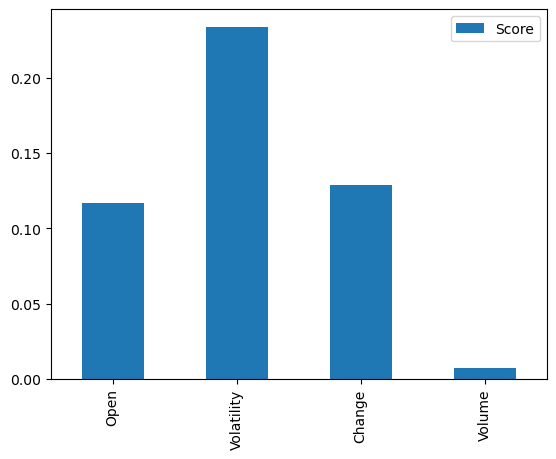

In [16]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt
%matplotlib inline
bestfeatures = SelectKBest(score_func=chi2, k='all')
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
scores = pd.concat([dfcolumns,dfscores],axis=1)
scores.columns = ['Specs','Score']
scores.index = features
scores.plot(kind='bar')
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

Entferne auf Grundlage dieser Informationen alle schwach bewerteten Features mit ``.remove()``.

In [21]:
# entferne alle schwach bewerteten Features mit features.remove('')
features.remove('Volume')
print(features)

['Open', 'Volatility', 'Change']


![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

#### Bedeutung von Features mit Entscheidungsbäumen

Es gibt eine Methode in einem baumbasierten Klassifikator, die für jedes Feature der Daten einen Score liefert. Ein höherer Score korreliert mit größerer Bedeutung und Relevanz für die Vorhersage der Zielvariablen. Die Ergebnisse ändern sich bei jeder Analyse aufgrund der stochastischen Natur der Berechnung, aber ``Volatility`` ist erneut ein Faktor, der typischerweise am höchsten rangiert.

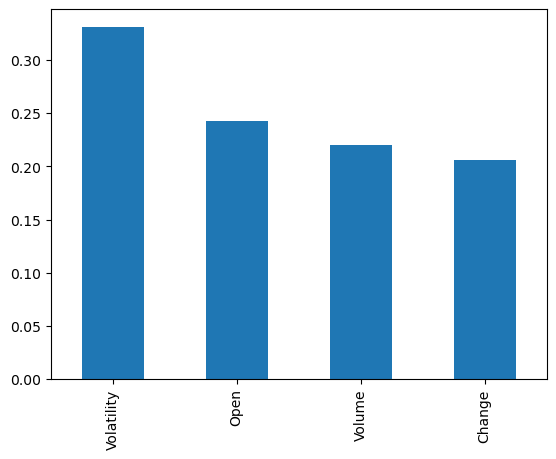

In [24]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier(n_estimators=100)
model.fit(X,np.ravel(y))

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(4).plot(kind='bar')
plt.show()

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

#### Korrelationsmatrix mit Heatmap

Korrelation zeigt, wie stark Features miteinander zusammenhängen. Ein großer Wert, positiv oder negativ, bedeutet, dass die Werte stark korreliert sind. Korrelation kann bedeuten, dass eines der Features entfallen kann, weil beide ähnliche Informationen liefern.

Eine Heatmap ist ein symmetrisches, visuelles Raster der Korrelationsmatrix und ein Standard zur Visualisierung. Die Diagonale ist immer 1, da jeder Wert perfekt mit sich selbst korreliert. Bestimme anhand der Heatmap, welche Features am stärksten korreliert sind.

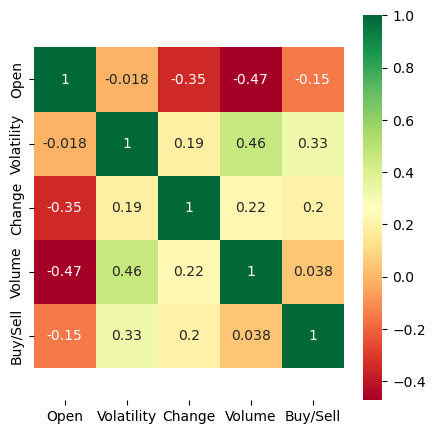

In [29]:
import seaborn as sns
corrmat = ds.corr()
top_features = corrmat.index
plt.figure(figsize=(5,5))
sns.heatmap(ds[top_features].corr(),annot=True,cmap="RdYlGn")
b, t = plt.ylim(); plt.ylim(b+0.5, t-0.5) # behebt ein Problem in matplotlib 3.1.1
plt.show()

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### TCLab-Übung

Überlege, wie du erkennen könntest, ob der TCLab-Heizer ein- oder ausgeschaltet ist, ohne den Wert ``Q1`` zu kennen. Wahrscheinlich würdest du die Temperatur T1 messen und beobachten, ob sie steigt oder fällt. Allein Temperatur und Steigung zu betrachten reicht jedoch nicht aus, weil die Temperatur noch 10–20 Sekunden weiter ansteigt, nachdem der Heizer ausgeschaltet wurde. Daher musst du die zweite Ableitung der Temperatur berechnen, um den Heizerzustand als „ein“ oder „aus“ zu klassifizieren. Eine positive zweite Ableitung ist ein weiterer Hinweis darauf, dass der Heizer eingeschaltet ist.

![temperature](https://apmonitor.com/che263/uploads/Begin_Python/temperature.png)

Im Fall „Heizer an oder aus“ (*gemessenes Ergebnis*) sind die Temperatur und ihre Ableitungen die *Features*. Führe den folgenden Code aus, um Temperaturdaten zu erzeugen, bei denen der Heizer in Intervallen von 20–30 Sekunden über 3 Minuten hinweg entweder mit 100 % ``on`` oder mit 0 % ``off`` ist.

In [58]:
import tclab, time
import numpy as np
import pandas as pd
try:
    with tclab.TCLab() as lab:
        n = 180; t = np.linspace(0,n-1,n)        
        Q1 = np.zeros(n); T1 = np.zeros(n)
        Q2 = np.zeros(n); T2 = np.zeros(n)        
        Q1[20:41] = 100.0; Q1[60:91] = 100.0
        Q1[150:181] = 100.0; Q1[190:206] = 100.0
        Q1[220:251] = 100.0; Q1[260:291] = 100.0
        print('Time Q1 Q2 T1   T2')
        for i in range(180):
            T1[i] = lab.T1; T2[i] = lab.T2
            lab.Q1(Q1[i])
            if i%10==0:
                print(int(t[i]),Q1[i],Q2[i],T1[i],T2[i])
            time.sleep(1)
    data = np.column_stack((t,Q1,Q2,T1,T2))
    data7 = pd.DataFrame(data,columns=['Time','Q1','Q2','T1','T2'])
    data7.to_csv('07-tclab.csv',index=False)
except:
    print('Connect TCLab to generate new data')
    print('Importing data from online source')
    url = 'http://apmonitor.com/do/uploads/Main/tclab_data5.txt'
    data7=pd.read_csv(url)

TCLab version 1.0.0
Arduino Leonardo connected on port COM7 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
Time Q1 Q2 T1   T2
0 0.0 0.0 20.866 20.254
10 0.0 0.0 20.866 20.254
20 100.0 0.0 20.866 20.254
30 100.0 0.0 21.253 20.254
40 100.0 0.0 22.864 20.318
50 0.0 0.0 25.088 20.576
60 100.0 0.0 26.699 20.898
70 100.0 0.0 27.988 21.221
80 100.0 0.0 30.051 21.575
90 100.0 0.0 32.693 22.091
100 0.0 0.0 35.368 22.51
110 0.0 0.0 36.689 23.154
120 0.0 0.0 37.334 23.799
130 0.0 0.0 37.334 24.347
140 0.0 0.0 36.979 24.733
150 100.0 0.0 36.335 25.088
160 100.0 0.0 36.045 25.41
170 100.0 0.0 36.786 25.765
TCLab disconnected successfully.


### Features erstellen

Erzeuge drei Features aus den Daten, einschließlich der Temperatur und ihrer Ableitungen.

- Temperatur: $T_1$
- Temperaturableitung: $\frac{dT_1}{dt}$
- Zweite Temperaturableitung: $\frac{d^2T_1}{dt^2}$

Füge die Ableitungen als Spalten in ``data7`` hinzu.

In [64]:
import numpy as np

# Zeit und Temperatur als NumPy-Arrays
t = data7["Time"].values
T1 = data7["T1"].values

# Zeitabstand (angenommen konstant)
dt = np.mean(np.diff(t))

# Erste Ableitung dT1/dt (numerisch)
dT1_dt = np.gradient(T1, dt)

# Zweite Ableitung d²T1/dt² (numerisch)
d2T1_dt2 = np.gradient(dT1_dt, dt)

# Neue Spalten zu data7 hinzufügen
data7["dT1_dt"] = dT1_dt
data7["d2T1_dt2"] = d2T1_dt2

# Kontrolle anzeigen
data7.head()


,Time,Q1,Q2,T1,T2,dT1_dt,d2T1_dt2
0,0.0,0.0,0.0,20.866,20.254,-0.032,0.048
1,1.0,0.0,0.0,20.834,20.254,0.016,0.016
2,2.0,0.0,0.0,20.898,20.254,0.000,-0.024
3,3.0,0.0,0.0,20.834,20.254,-0.032,0.016
4,4.0,0.0,0.0,20.834,20.254,0.032,0.032


### Daten skalieren

Skaliere ``data7`` auf den Bereich ``0`` bis ``1`` mit ``d7 = s.fit_transform(data7)``. Vergiss nicht, die skalierten Werte zurück in ein ``pandas``-DataFrame zu übertragen.

In [67]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# MinMaxScaler erstellen
s = MinMaxScaler(feature_range=(0, 1))

# Daten skalieren
d7 = s.fit_transform(data7)

# Zurück in ein pandas-DataFrame mit gleichen Spaltennamen
d7 = pd.DataFrame(d7, columns=data7.columns)

# Kontrolle anzeigen
d7.head()


,Time,Q1,Q2,T1,T2,dT1_dt,d2T1_dt2
0,0.000000,0.0,0.0,0.005476,0.037498,0.266805,0.814972
1,0.005587,0.0,0.0,0.003651,0.037498,0.366081,0.634181
2,0.011173,0.0,0.0,0.007301,0.037498,0.332989,0.408192
3,0.016760,0.0,0.0,0.003651,0.037498,0.266805,0.634181
4,0.022346,0.0,0.0,0.003651,0.037498,0.399173,0.724576


### Features bewerten

Verwende ``SelectKBest``, um die besten Features zu bestimmen.

In [70]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

# Zielvariable definieren (z.B. T1 vorhersagen)
y = d7["T1"]

# Feature-Matrix (alle anderen Spalten außer Ziel)
X = d7.drop(columns=["T1"])

# SelectKBest mit Regressions-Score
selector = SelectKBest(score_func=f_regression, k="all")
X_new = selector.fit_transform(X, y)

# Scores der Features anzeigen
scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

# Nach Wichtigkeit sortieren
scores = scores.sort_values(by="Score", ascending=False)

scores


,Feature,Score
0,Time,1477.831435
3,T2,875.073408
4,dT1_dt,2.820185
5,d2T1_dt2,1.827447
1,Q1,1.179676
2,Q2,0.000000


### Feature-Korrelation

Erzeuge eine Heatmap, um die Korrelation der Features zu bestimmen.

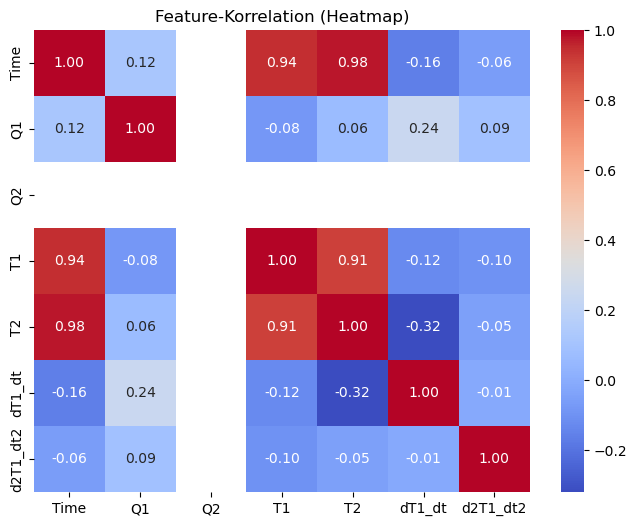

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Korrelationsmatrix berechnen
corr = d7.corr()

# Heatmap erstellen
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

# Titel hinzufügen
plt.title("Feature-Korrelation (Heatmap)")

# Diagramm anzeigen
plt.show()


### Verständnisfragen:
Warum gibt es eine so hohe Korrelation zwischen T1 und T2?
Welches Feature sollte noch entfernt werden aus der Matrix?